# XGBOOST HIERARCHICAL DIABETES CLASSIFICATION

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import xgboost

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

In [2]:
dataset = pd.read_csv("../../datasets/processed/cdc_diabetes_012.csv" , sep = "," , encoding = 'utf-8')
print("Dataset Shape: ", dataset.shape)
dataset

Dataset Shape:  (140283, 12)


,Diabetes_012,HighBP,HighChol,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,GenHlth,MentHlth,PhysHlth,DiffWalk,Age
0,0.0,1.0,1.0,40.0,1.0,0.0,0.0,5.0,18.0,15.0,1.0,9.0
1,0.0,0.0,0.0,25.0,1.0,0.0,1.0,3.0,0.0,0.0,0.0,7.0
2,0.0,1.0,1.0,28.0,0.0,0.0,0.0,5.0,30.0,30.0,1.0,9.0
3,0.0,1.0,0.0,27.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,11.0
4,0.0,1.0,1.0,24.0,0.0,0.0,1.0,2.0,3.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...
140278,0.0,1.0,1.0,23.0,0.0,1.0,0.0,4.0,0.0,5.0,0.0,8.0
140279,0.0,1.0,0.0,42.0,0.0,0.0,1.0,3.0,14.0,4.0,0.0,3.0
140280,0.0,1.0,1.0,45.0,0.0,0.0,0.0,3.0,0.0,5.0,0.0,5.0
140281,2.0,1.0,1.0,18.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,11.0


In [8]:
dataset = dataset[dataset['Diabetes_012'] != 0] 
print("Dataset Shape after filtering: ", dataset.shape)

dataset["Diabetes_012"] = dataset["Diabetes_012"].map({
    1: 0,
    2: 1
})

Dataset Shape after filtering:  (33483, 12)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18248\3428225457.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Diabetes_012"] = dataset["Diabetes_012"].map({


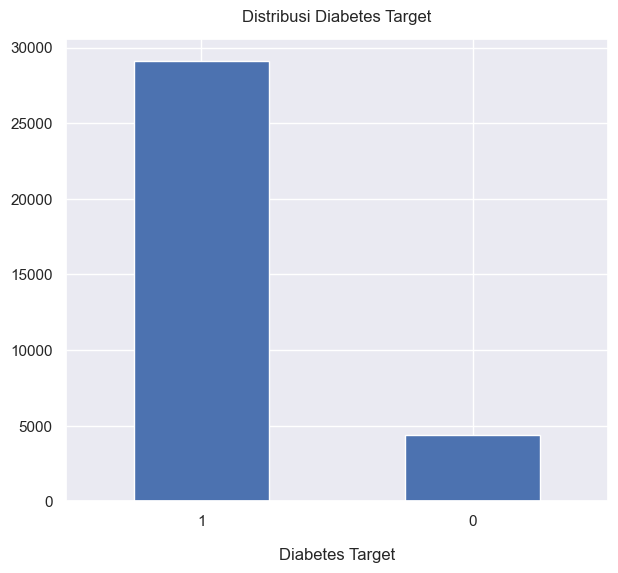

Diabetes_012
1    29097
0     4386
Name: count, dtype: int64


In [9]:
sns.set(font_scale=1.0)
dataset['Diabetes_012'].value_counts().plot(kind='bar', figsize=(7, 6), rot=0)
plt.xlabel("Diabetes Target", labelpad=14)
plt.title("Distribusi Diabetes Target", y=1.02);
plt.show()

print(dataset['Diabetes_012'].value_counts())

# Balancing Data

In [10]:
X = dataset.drop(['Diabetes_012'], axis = 1).values
y = dataset['Diabetes_012']

## Over-Sampling SMOTE

In [11]:
# SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = SMOTE().fit_resample(X, y)

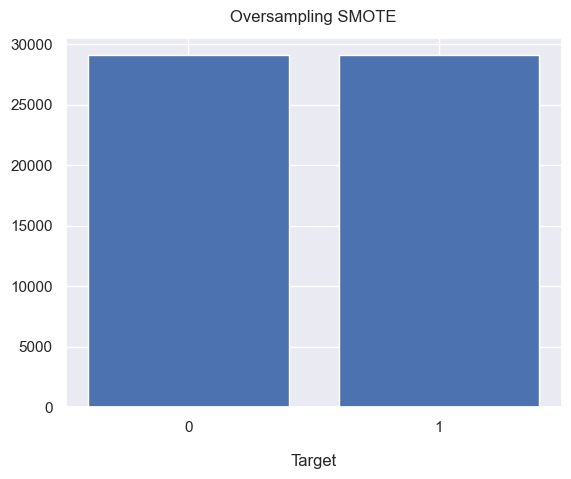

Diabetes_012
1    29097
0    29097
Name: count, dtype: int64

In [12]:
# Oversampling SMOTE
sns.set(font_scale=1.0)
smote_counts = y_resampled_smote.value_counts()

plt.bar(smote_counts.index, smote_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Oversampling SMOTE", y=1.02);
plt.show()

smote_counts

## Under-Sampling RandomUnderSampler

In [15]:
# RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled_rus, y_resampled_rus = rus.fit_resample(X, y)

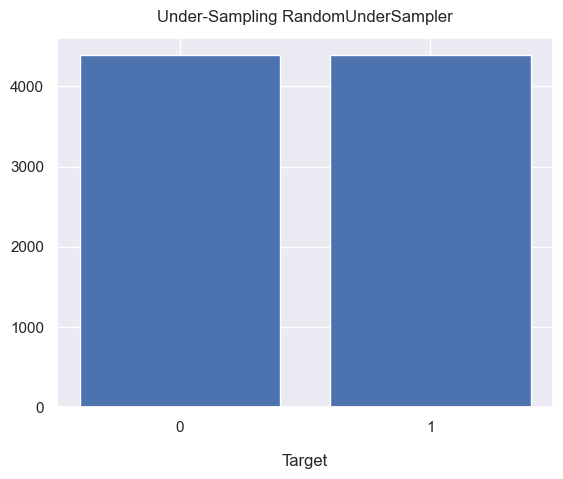

Diabetes_012
0    4386
1    4386
Name: count, dtype: int64

In [16]:
# Under-Sampling RandomUnderSampler
sns.set(font_scale=1.0)
rus_counts = y_resampled_rus.value_counts()

plt.bar(rus_counts.index, rus_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Under-Sampling RandomUnderSampler", y=1.02);
plt.show()

rus_counts

## Over- and Under-Sampling SMOTEENN

In [17]:
# SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_resampled_smoteenn, y_resampled_smoteenn = smoteenn.fit_resample(X, y)

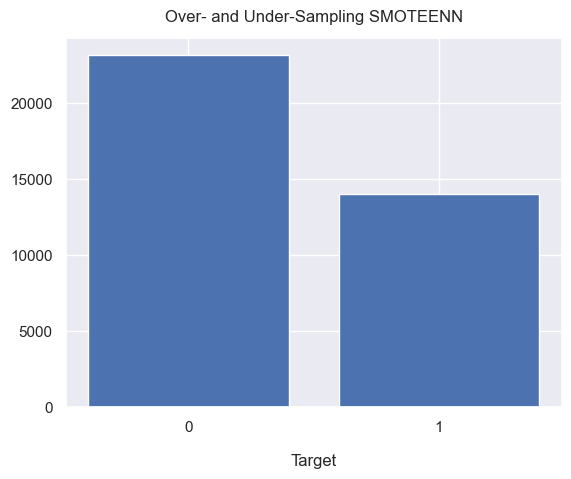

Diabetes_012
0    23145
1    13999
Name: count, dtype: int64

In [18]:
# Over- and Under-Sampling SMOTEENN
sns.set(font_scale=1.0)
smoteenn_counts = y_resampled_smoteenn.value_counts()

plt.bar(smoteenn_counts.index, smoteenn_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Over- and Under-Sampling SMOTEENN", y=1.02);
plt.show()

smoteenn_counts

# Split Data

In [19]:
#Data Raw
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(26786, 6697, 26786, 6697)

In [20]:
# Oversampling SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_resampled_smote, y_resampled_smote,
                                                                            test_size=0.2, random_state=42)
len(X_train_smote), len(X_test_smote), len(y_train_smote), len(y_test_smote)

(46555, 11639, 46555, 11639)

In [21]:
# Under-Sampling RandomUnderSampler
X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(X_resampled_rus, y_resampled_rus,
                                                                    test_size=0.2, random_state=42)
len(X_train_rus), len(X_test_rus), len(y_train_rus), len(y_test_rus)

(7017, 1755, 7017, 1755)

In [22]:
# Over- and Under-Sampling SMOTEENN
X_train_smoteenn, X_test_smoteenn, y_train_smoteenn, y_test_smoteenn = train_test_split(X_resampled_smoteenn, y_resampled_smoteenn,
                                                                    test_size=0.2, random_state=42)
len(X_train_smoteenn), len(X_test_smoteenn), len(y_train_smoteenn), len(y_test_smoteenn)

(29715, 7429, 29715, 7429)

# Model

In [23]:
# Raw Data
model = xgboost.XGBClassifier()
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
# Over-Sampling SMOTE
model_smote = xgboost.XGBClassifier()
model_smote.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
# Under-Sampling RandomUnderSampler
model_rus = xgboost.XGBClassifier()
model_rus.fit(X_train_rus, y_train_rus)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
# Over and Under-Sampling SMTOEENN
model_smoteenn = xgboost.XGBClassifier()
model_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Evalution

In [27]:
# Raw Data
y_test_pred = model.predict(X_test)

print("\nTest Set:")
print(classification_report(y_test, y_test_pred))

accuracy_test = accuracy_score(y_test, y_test_pred)

print("\nTest Set Accuracy:", accuracy_test)


Test Set:
              precision    recall  f1-score   support

           0       0.13      0.01      0.01       861
           1       0.87      0.99      0.93      5836

    accuracy                           0.87      6697
   macro avg       0.50      0.50      0.47      6697
weighted avg       0.78      0.87      0.81      6697


Test Set Accuracy: 0.867104673734508


In [28]:
# Over-Sampling SMOTE
y_test_pred_smote = model_smote.predict(X_test_smote)

print("\nTest Set:")
print(classification_report(y_test_smote, y_test_pred_smote))

accuracy_test_smote = accuracy_score(y_test_smote, y_test_pred_smote)

print("\nTest Set Accuracy:", accuracy_test_smote)


Test Set:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      5850
           1       0.86      0.99      0.92      5789

    accuracy                           0.92     11639
   macro avg       0.93      0.92      0.92     11639
weighted avg       0.93      0.92      0.92     11639


Test Set Accuracy: 0.9170031789672652


In [29]:
# Under-Sampling RandomUnderSampler
y_test_pred_rus = model_rus.predict(X_test_rus)

print("\nTest Set:")
print(classification_report(y_test_rus, y_test_pred_rus))

accuracy_test_rus = accuracy_score(y_test_rus, y_test_pred_rus)

print("\nTest Set Accuracy:", accuracy_test_rus)


Test Set:
              precision    recall  f1-score   support

           0       0.57      0.56      0.56       876
           1       0.57      0.58      0.57       879

    accuracy                           0.57      1755
   macro avg       0.57      0.57      0.57      1755
weighted avg       0.57      0.57      0.57      1755


Test Set Accuracy: 0.5680911680911681


In [30]:
# Over and Under-Sampling SMTOEENN
y_test_pred_smoteenn = model_smoteenn.predict(X_test_smoteenn)

print("\nTest Set:")
print(classification_report(y_test_smoteenn, y_test_pred_smoteenn))

accuracy_test_smoteenn = accuracy_score(y_test_smoteenn, y_test_pred_smoteenn)

print("\nTest Set Accuracy:", accuracy_test_smoteenn)


Test Set:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92      4655
           1       0.83      0.95      0.88      2774

    accuracy                           0.91      7429
   macro avg       0.90      0.92      0.90      7429
weighted avg       0.92      0.91      0.91      7429


Test Set Accuracy: 0.9073899582716382


# Comparison

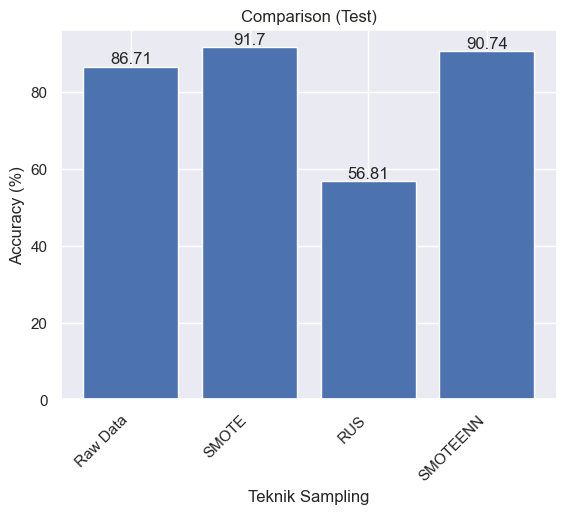

In [31]:
model_comp = pd.DataFrame({'Teknik Sampling': ['Raw Data','SMOTE','RUS', 'SMOTEENN'],
                           'Accuracy': [accuracy_test*100, accuracy_test_smote*100, accuracy_test_rus*100, accuracy_test_smoteenn*100]})

fig, ax = plt.subplots()
bars = plt.bar(model_comp['Teknik Sampling'], model_comp['Accuracy'])
plt.xlabel('Teknik Sampling')
plt.ylabel('Accuracy (%)')
plt.title('Comparison (Test)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()

In [32]:
import joblib
joblib.dump(model_smote, '../../models/se/xgboost_12feat_stage2.pkl')

['../../models/se/xgboost_12feat_stage2.pkl']